In [1]:
import pandas as pd
import matplotlib.pyplot as plt

PATH = "./data/"

df = pd.read_csv(PATH+"crashes_cleaned.csv")

In [2]:
df.head()

,Unnamed: 0,Date,Time,Location,Operator,Flight #,Route,AC Type,Aboard,Fatalities,Ground,Year,AC mfr,Departure,Arrival
0,0,1908-09-17,1718,"Fort Myer, Virginia",military,?,Demonstration,Wright Flyer III,2.0,1.0,0,1908,wright,?,?
1,1,1909-09-07,?,"Juvisy-sur-Orge, France",?,?,Air show,Wright Byplane,1.0,1.0,0,1909,wright,?,?
2,2,1912-07-12,0630,"Atlantic City, New Jersey",military,?,Test flight,Dirigible,5.0,5.0,0,1912,dirigible,?,?
3,3,1913-08-06,?,"Victoria, British Columbia, Canada",private,?,?,Curtiss seaplane,1.0,1.0,0,1913,curtiss,?,?
4,4,1913-09-09,1830,Over the North Sea,military,?,?,Zeppelin L-1 (airship),20.0,14.0,0,1913,zeppelin,?,?


## Basic Statistics

In [3]:
nb_crashes = len(df.index)
nb_military = len(df[df["Operator"] == "military"])
dstnct_operator = df["Operator"].str.lower().nunique() - 1
dstnct_ac_mfr = df["AC mfr"].str.lower().nunique()
dstnct_ac_type = df["AC Type"].str.lower().nunique()
nb_routes = nb_crashes - len(df[(df["Departure"] == "?") | (df["Arrival"] == "?")])

print(f"There are {nb_crashes} crashes reported in this dataset.")
print(f"{nb_military} of these crashes are from military flights.")
print(f"{dstnct_operator} distinct operators are recorded, execluding military operators.")
print(f"The dataset contains {dstnct_ac_mfr} distinct aircraft manufacturers and {dstnct_ac_type} distinct planes.")
print(f"We know the exact route of {nb_routes} flights.")


There are 5078 crashes reported in this dataset.
753 of these crashes are from military flights.
1962 distinct operators are recorded, execluding military operators.
The dataset contains 307 distinct aircraft manufacturers and 2425 distinct planes.
We know the exact route of 4053 flights.


## Accidents per Year

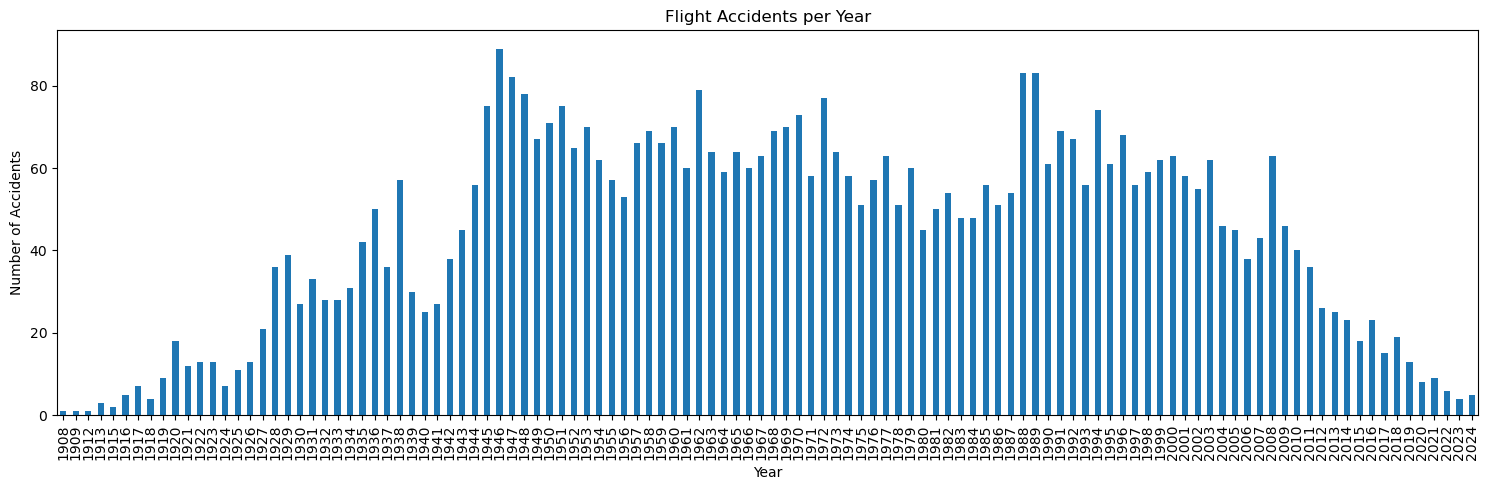

In [4]:
accidents_per_year = df["Year"].value_counts().sort_index()


accidents_per_year.plot(kind="bar", figsize=(15, 5))
plt.title("Flight Accidents per Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.tight_layout()

## Accidents by Operator

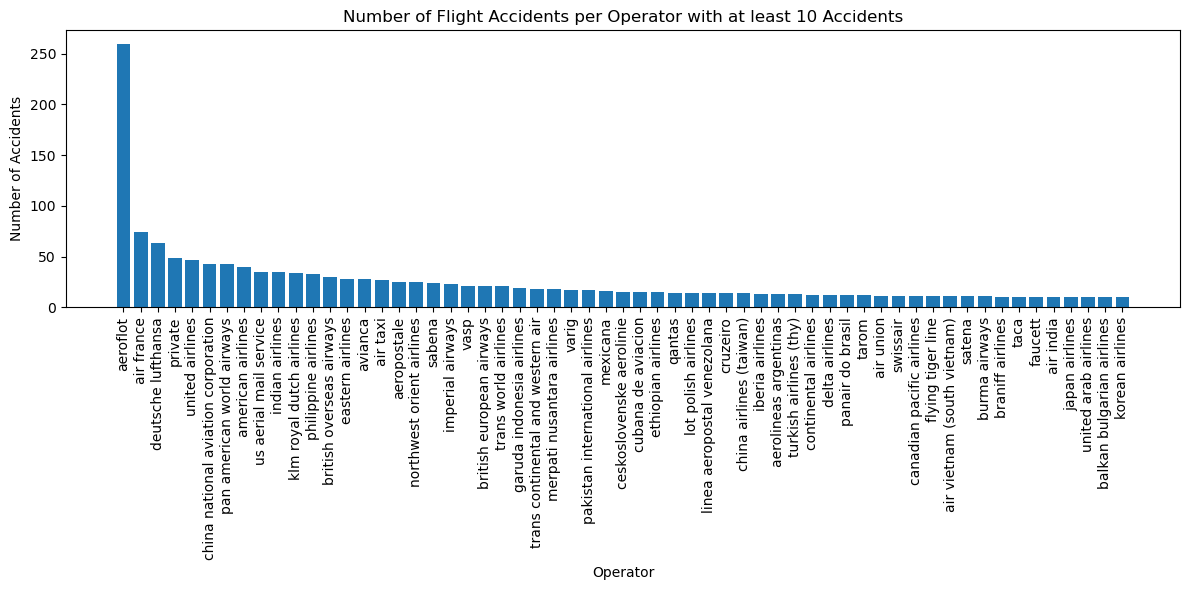

In [5]:
operator_count = df[~df["Operator"].isin(["military", "?"])]["Operator"].value_counts().reset_index()
operator_count = operator_count[operator_count["count"]>=10]

plt.figure(figsize=(12, 6))
plt.bar(operator_count["Operator"], operator_count["count"])
plt.xlabel("Operator")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=90)
plt.title("Number of Flight Accidents per Operator with at least 10 Accidents")
plt.tight_layout()

## Accidents by Manufacturer

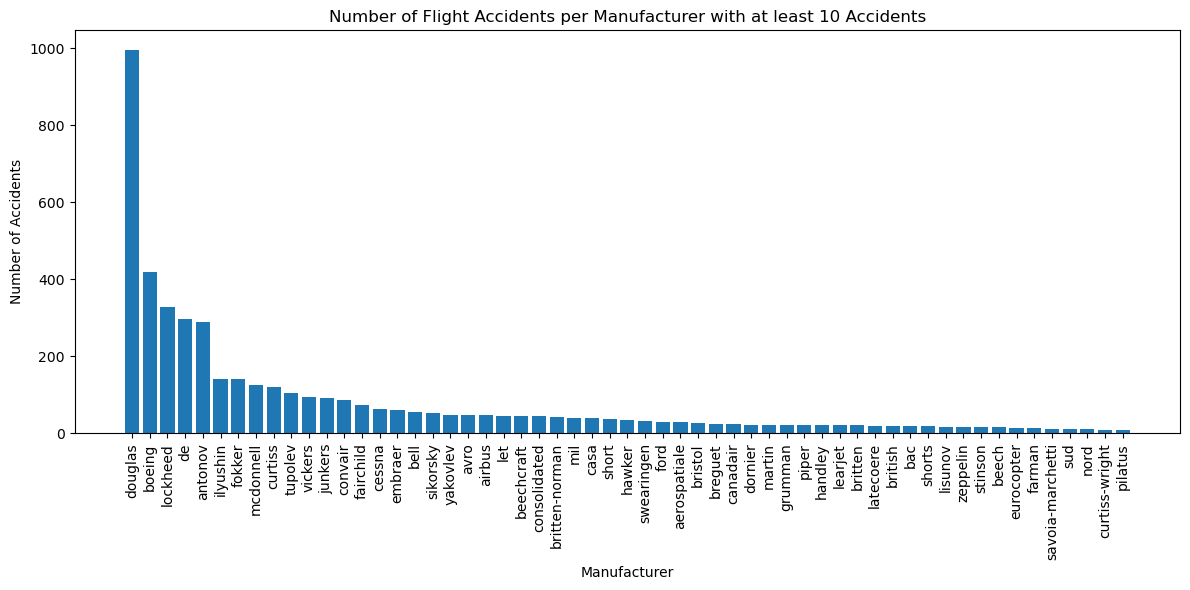

In [6]:
mfr_count = df[df["AC mfr"] != "?"]["AC mfr"].value_counts().reset_index()
mfr_count = mfr_count[mfr_count["count"]>=10]

plt.figure(figsize=(12, 6))
plt.bar(mfr_count["AC mfr"], mfr_count["count"])
plt.xlabel("Manufacturer")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=90)
plt.title("Number of Flight Accidents per Manufacturer with at least 10 Accidents")
plt.tight_layout()

## Survivorship

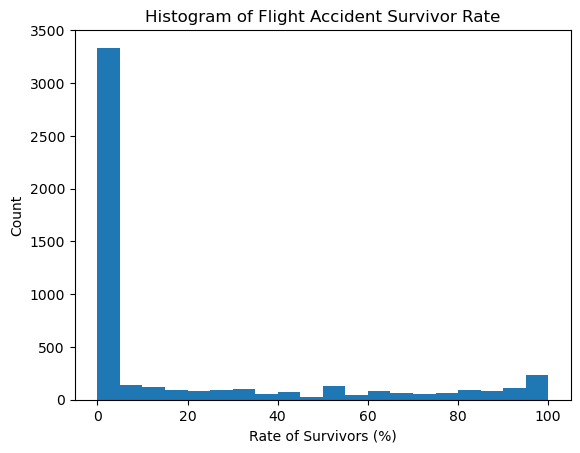

In [7]:
survivors = df[["Aboard", "Fatalities"]]
survivors["Survivors"] = survivors["Aboard"] - survivors["Fatalities"]
survivors["Rate"] = survivors["Survivors"].div(survivors["Aboard"]) * 100

plt.hist(survivors["Rate"], bins=20)
plt.xlabel("Rate of Survivors (%)")
plt.ylabel("Count")
plt.title("Histogram of Flight Accident Survivor Rate")
plt.show()